In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skt


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

data = pd.read_csv("data/world_real_estate_data(147k).csv")
print(data.head())

                                               title   country  \
0  2 room apartment 120 m² in Mediterranean Regio...    Turkey   
1              4 room villa 500 m² in Kalkan, Turkey    Turkey   
2          1 room apartment 65 m² in Antalya, Turkey    Turkey   
3             1 room apartment  in Pattaya, Thailand  Thailand   
4             2 room apartment  in Pattaya, Thailand  Thailand   

                                    location  building_construction_year  \
0               Mediterranean Region, Turkey                         NaN   
1  Kalkan, Mediterranean Region, Kas, Turkey                      2021.0   
2      Mediterranean Region, Antalya, Turkey                         NaN   
3      Chon Buri Province, Pattaya, Thailand                      2020.0   
4      Chon Buri Province, Pattaya, Thailand                      2026.0   

   building_total_floors  apartment_floor  apartment_rooms  \
0                    5.0              1.0              3.0   
1                    2

In [8]:
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          36982 non-null   float64
 8   apartment_bathrooms         55973 non-null   float64
 9   apartment_total_area        141796 non-null  object 
 10  apartment_living_area       27712 non-null   object 
 11  price_in_USD                144961 non-null  float64
 12  image                       147536 non-null  object 
 13  url           

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


In [9]:
data.isnull().sum()

title                              0
country                          130
location                         131
building_construction_year     82817
building_total_floors          79312
apartment_floor                92944
apartment_rooms                73358
apartment_bedrooms            110554
apartment_bathrooms            91563
apartment_total_area            5740
apartment_living_area         119824
price_in_USD                    2575
image                              0
url                                0
dtype: int64

In [10]:
df= data.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (147536, 14)


In [11]:
numeric_cols = data.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

In [12]:
text_cols = data.select_dtypes(include=['object']).columns

for col in text_cols:
    data[col] = data[col].fillna("Unknown")

In [13]:
data.isnull().sum()

title                         0
country                       0
location                      0
building_construction_year    0
building_total_floors         0
apartment_floor               0
apartment_rooms               0
apartment_bedrooms            0
apartment_bathrooms           0
apartment_total_area          0
apartment_living_area         0
price_in_USD                  0
image                         0
url                           0
dtype: int64

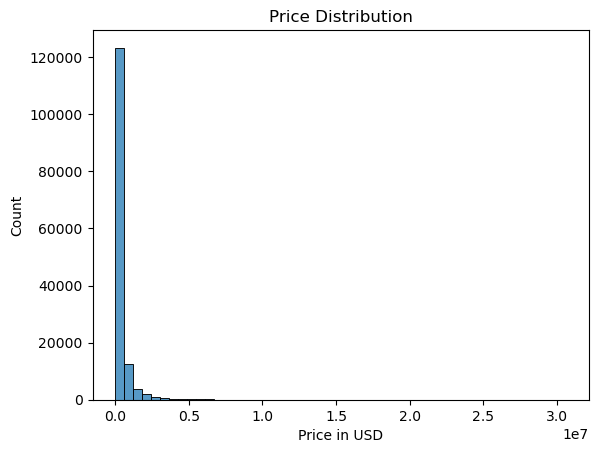

In [31]:
plt.figure()

sns.histplot(df['price_in_USD'], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price in USD")
plt.ylabel("Count")

plt.show()

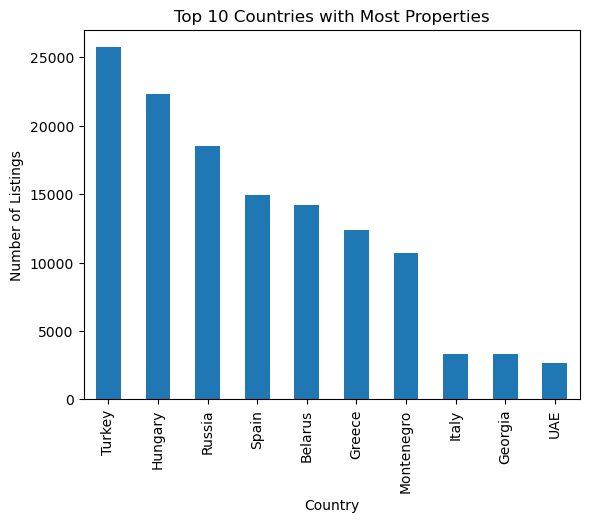

In [32]:
plt.figure()
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries with Most Properties")
plt.xlabel("Country")
plt.ylabel("Number of Listings")
plt.show()

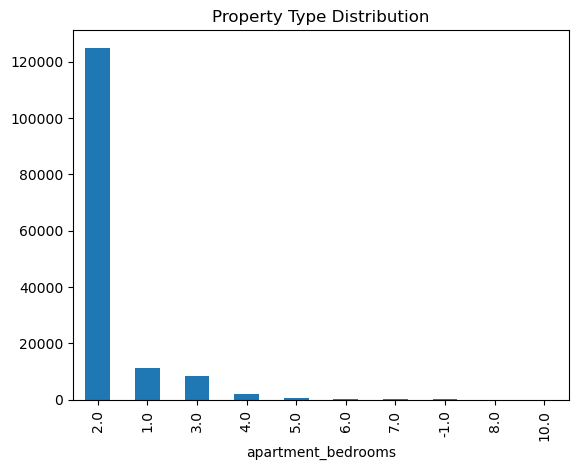

In [41]:
import matplotlib.pyplot as plt

plt.figure()
data['apartment_bedrooms'].value_counts().head(10).plot(kind='bar')
plt.title("Property Type Distribution")
plt.show()

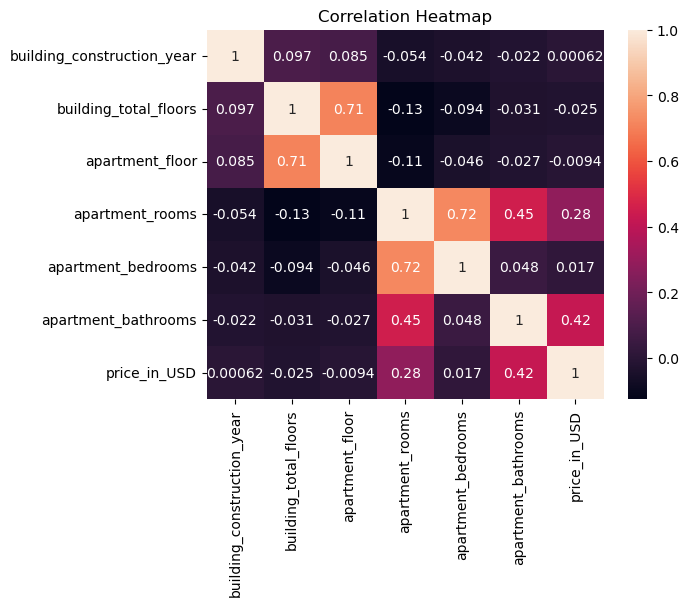

In [42]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [43]:
data.to_csv("cleaned_real_estate_data.csv", index=False)

In [44]:
from sklearn.model_selection import train_test_split

# X = independent variables (features)
X = data.drop('price_in_USD', axis=1)

# y = dependent variable (target)
y = data['price_in_USD']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shape
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (118028, 13)
Testing data shape: (29508, 13)


In [49]:
X_train.dtypes

title                          object
country                        object
location                       object
building_construction_year    float64
building_total_floors         float64
apartment_floor               float64
apartment_rooms               float64
apartment_bedrooms            float64
apartment_bathrooms           float64
apartment_total_area           object
apartment_living_area          object
image                          object
url                            object
dtype: object

In [50]:
X = data.drop(['title'], axis=1)

In [53]:
X = data.drop(['image'], axis=1)

In [54]:
X = df.drop(['url'], axis=1)

In [58]:
X = pd.get_dummies(X, columns=['apartment_living_area','apartment_total_area','location'], drop_first=True)

In [61]:
X.dtypes

title                          object
country                        object
location                       object
building_construction_year    float64
building_total_floors         float64
apartment_floor               float64
apartment_rooms               float64
apartment_bedrooms            float64
apartment_bathrooms           float64
apartment_total_area           object
apartment_living_area          object
image                          object
url                            object
dtype: object

In [62]:
X = X.select_dtypes(include=['int64','float64'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

In [64]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.01761639769866219


In [65]:
sample_house = [[2000, 3, 2, 5]]

In [67]:
print(X.columns)

Index(['building_construction_year', 'building_total_floors',
       'apartment_floor', 'apartment_rooms', 'apartment_bedrooms',
       'apartment_bathrooms'],
      dtype='object')


In [68]:
sample_house = [[2000, 3, 2, 5, 1, 0]]

In [69]:
predicted_price = model.predict(sample_house)

print("Predicted House Price:", predicted_price)

Predicted House Price: [320092.63502389]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [70]:
import pandas as pd

# Create sample input (must match X.columns)
sample_house = pd.DataFrame([[2000, 3, 2, 5, 1, 0]], columns=X.columns)

# Predict price
predicted_price = model.predict(sample_house)

# Print labeled output
print("----- House Price Prediction -----")
print("Area (sqft):", sample_house.iloc[0,0])
print("Bedrooms:", sample_house.iloc[0,1])
print("Bathrooms:", sample_house.iloc[0,2])
print("Age of House:", sample_house.iloc[0,3])
print("Location Feature 1:", sample_house.iloc[0,4])
print("Location Feature 2:", sample_house.iloc[0,5])
print("----------------------------------")
print("Predicted House Price:", predicted_price[0])

----- House Price Prediction -----
Area (sqft): 2000
Bedrooms: 3
Bathrooms: 2
Age of House: 5
Location Feature 1: 1
Location Feature 2: 0
----------------------------------
Predicted House Price: 320092.6350238896
